# EDA

In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

In [33]:
# Load dataset
df = pd.read_csv('WineQT.csv')
df.drop(columns=['Id'], inplace=True)

In [34]:
# Basic shape & info
print(df.shape)      
print(df.dtypes)       
print(df.isnull().sum()) 

(1143, 12)
fixed acidity           float64
volatile acidity        float64
citric acid             float64
residual sugar          float64
chlorides               float64
free sulfur dioxide     float64
total sulfur dioxide    float64
density                 float64
pH                      float64
sulphates               float64
alcohol                 float64
quality                   int64
dtype: object
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64


In [35]:
# Target distribution
print(df['quality'].value_counts().sort_index())

quality
3      6
4     33
5    483
6    462
7    143
8     16
Name: count, dtype: int64


In [36]:
# Summary statistics
print(df.describe().round(3))

       fixed acidity  volatile acidity  citric acid  residual sugar  \
count       1143.000          1143.000     1143.000        1143.000   
mean           8.311             0.531        0.268           2.532   
std            1.748             0.180        0.197           1.356   
min            4.600             0.120        0.000           0.900   
25%            7.100             0.392        0.090           1.900   
50%            7.900             0.520        0.250           2.200   
75%            9.100             0.640        0.420           2.600   
max           15.900             1.580        1.000          15.500   

       chlorides  free sulfur dioxide  total sulfur dioxide   density  \
count   1143.000             1143.000              1143.000  1143.000   
mean       0.087               15.615                45.915     0.997   
std        0.047               10.250                32.782     0.002   
min        0.012                1.000                 6.000     0.99

# Feature Selection via Correlation
Pearson correlation reveals linear relationships between features and the target. High |r| → strong signal.

In [37]:
# Pearson correlation matrix
corr = df.corr()

# Correlation with target
target_corr = corr['quality'].drop('quality').abs().sort_values(ascending=False)

# Feature selection threshold
selected = target_corr[target_corr > 0.1].index.tolist()
print("Selected features:", selected)
# ['alcohol','volatile acidity','sulphates','citric acid','total SO2',...]

X = df[selected].values
y = df['quality'].values.reshape(-1, 1)

Selected features: ['alcohol', 'volatile acidity', 'sulphates', 'citric acid', 'total sulfur dioxide', 'density', 'chlorides', 'fixed acidity']


# Neural Network Matrix Implementation

In [42]:
# Split data into train and test sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Normalize features
scaler_X = StandardScaler()
X_train = scaler_X.fit_transform(X_train)
X_test = scaler_X.transform(X_test)

# Transform to correct shapes
X_train = X_train.T  # (11, m_train)
X_test = X_test.T    # (11, m_test)
y_train = y_train.T  # (1, m_train)
y_test = y_test.T    # (1, m_test)

print(f"X_train shape: {X_train.shape}")   # (11, samples)
print(f"y_train shape: {y_train.shape}")   # (1, samples)
print(f"X_test shape: {X_test.shape}")
print(f"y_test shape: {y_test.shape}")

X_train shape: (8, 914)
y_train shape: (1, 914)
X_test shape: (8, 229)
y_test shape: (1, 229)


# Neural Network Initialization

In [45]:
def init_params(layer_dims):
    """
    He initialization for ReLU networks.
    W ~ N(0, sqrt(2/n_in))
    b  = zeros
    """
    params = {}
    L = len(layer_dims)

    for l in range(1, L):
        n_in  = layer_dims[l - 1]
        n_out = layer_dims[l]

        # He scale factor
        scale = np.sqrt(2.0 / n_in)

        params[f'W{l}'] = np.random.randn(n_out, n_in) * scale
        params[f'b{l}'] = np.zeros((n_out, 1))

    return params

# Get the actual number of input features
n_features = X.shape[1]
print(f"Number of input features: {n_features}")

# Initialize network DYNAMICALLY based on actual number of features
# Architecture: [n_features] → [16] → [8] → [1]
np.random.seed(42)
params = init_params([n_features, 16, 8, 1])

print(f"Network Architecture: {n_features} → 16 → 8 → 1")
print(f"W1 shape: {params['W1'].shape}")
print(f"W2 shape: {params['W2'].shape}")
print(f"W3 shape: {params['W3'].shape}")

Number of input features: 8
Network Architecture: 8 → 16 → 8 → 1
W1 shape: (16, 8)
W2 shape: (8, 16)
W3 shape: (1, 8)


# Forward Pass & Backpropagation

In [46]:
# ── FORWARD PASS ────────────────────────
def forward(X, params):
    """
    Forward propagation through the network.
    X: (n_features, m) - input data
    params: weight and bias matrices
    Returns: predictions and cache for backprop
    """
    cache = {}
    A = X                      # (11, m)
    cache['A0'] = A
    L = len(params) // 2

    for l in range(1, L):      # hidden layers
        W = params[f'W{l}']
        b = params[f'b{l}']
        Z = W @ A + b
        cache[f'Z{l}'] = Z
        A = np.maximum(0, Z)   # ReLU
        cache[f'A{l}'] = A

    # Output layer
    W = params[f'W{L}']
    b = params[f'b{L}']
    Z = W @ A + b
    cache[f'Z{L}'] = Z
    A_out = 1 / (1 + np.exp(-Z))   # Sigmoid output
    cache[f'A{L}'] = A_out
    
    return A_out, cache

# ── BACKWARD PASS ───────────────────────
def backward(y_pred, y_true, params, cache):
    """
    Backward propagation through the network.
    y_pred: (1, m) - predictions
    y_true: (1, m) - true labels
    params: weight and bias matrices
    cache: activations and z values from forward pass
    Returns: gradients for all parameters
    """
    grads = {}
    m = y_true.shape[1]
    L = len(params) // 2

    # Output layer gradient (MSE + Sigmoid)
    dA = 2 * (y_pred - y_true) / m
    sig = y_pred * (1 - y_pred)
    dZ = dA * sig

    grads[f'dW{L}'] = (dZ @ cache[f'A{L-1}'].T) / m
    grads[f'db{L}'] = np.sum(dZ, axis=1, keepdims=True) / m
    dA_prev = params[f'W{L}'].T @ dZ

    # Hidden layers (backward through ReLU)
    for l in range(L-1, 0, -1):
        dZ = dA_prev * (cache[f'Z{l}'] > 0)  # ReLU gradient
        grads[f'dW{l}'] = (dZ @ cache[f'A{l-1}'].T) / m
        grads[f'db{l}'] = np.sum(dZ, axis=1, keepdims=True) / m
        if l > 1:
            dA_prev = params[f'W{l}'].T @ dZ
    
    return grads

# ── WEIGHT UPDATE ───────────────────────
def update(params, grads, lr):
    """Update parameters using gradient descent."""
    L = len(params) // 2
    for l in range(1, L + 1):
        params[f'W{l}'] -= lr * grads[f'dW{l}']
        params[f'b{l}'] -= lr * grads[f'db{l}']
    return params

In [47]:
# ── TRAINING LOOP ───────────────────────
def train(X, y, params, epochs=500, lr=0.01):
    """
    Train the neural network.
    Returns: params (trained), losses (training history)
    """
    losses = []
    
    for epoch in range(epochs):
        # Forward pass
        y_pred, cache = forward(X, params)
        
        # Compute MSE loss
        loss = np.mean((y_pred - y) ** 2)
        losses.append(loss)
        
        # Backward pass
        grads = backward(y_pred, y, params, cache)
        
        # Update parameters
        params = update(params, grads, lr)
        
        if (epoch + 1) % (epochs // 10) == 0 or epoch == 0:
            print(f"Epoch {epoch+1}/{epochs} | Loss: {loss:.6f}")
    
    return params, losses

# ── PREDICTION ───────────────────────────
def predict(X, params):
    """Make predictions on new data."""
    y_pred, _ = forward(X, params)
    return y_pred

# ── EVALUATION ────────────────────────────
def mse(y_pred, y_true):
    """Mean Squared Error"""
    return np.mean((y_pred - y_true) ** 2)

def mae(y_pred, y_true):
    """Mean Absolute Error"""
    return np.mean(np.abs(y_pred - y_true))

# Train the network
print("Training Neural Network...")
params, losses = train(X_train, y_train, params, epochs=500, lr=0.01)

# Evaluate on test set
y_pred_train = predict(X_train, params)
y_pred_test = predict(X_test, params)

train_mse = mse(y_pred_train, y_train)
test_mse = mse(y_pred_test, y_test)
train_mae = mae(y_pred_train, y_train)
test_mae = mae(y_pred_test, y_test)

print(f"\nTraining Results:")
print(f"Train MSE: {train_mse:.6f} | Train MAE: {train_mae:.4f}")
print(f"Test MSE:  {test_mse:.6f} | Test MAE:  {test_mae:.4f}")

Training Neural Network...
Epoch 1/500 | Loss: 27.911996
Epoch 50/500 | Loss: 27.886844
Epoch 100/500 | Loss: 27.861270
Epoch 150/500 | Loss: 27.835821
Epoch 200/500 | Loss: 27.810462
Epoch 250/500 | Loss: 27.785109
Epoch 300/500 | Loss: 27.759787
Epoch 350/500 | Loss: 27.734468
Epoch 400/500 | Loss: 27.709155
Epoch 450/500 | Loss: 27.683901
Epoch 500/500 | Loss: 27.658674

Training Results:
Train MSE: 27.658170 | Train MAE: 5.1931
Test MSE:  27.707824 | Test MAE:  5.2071


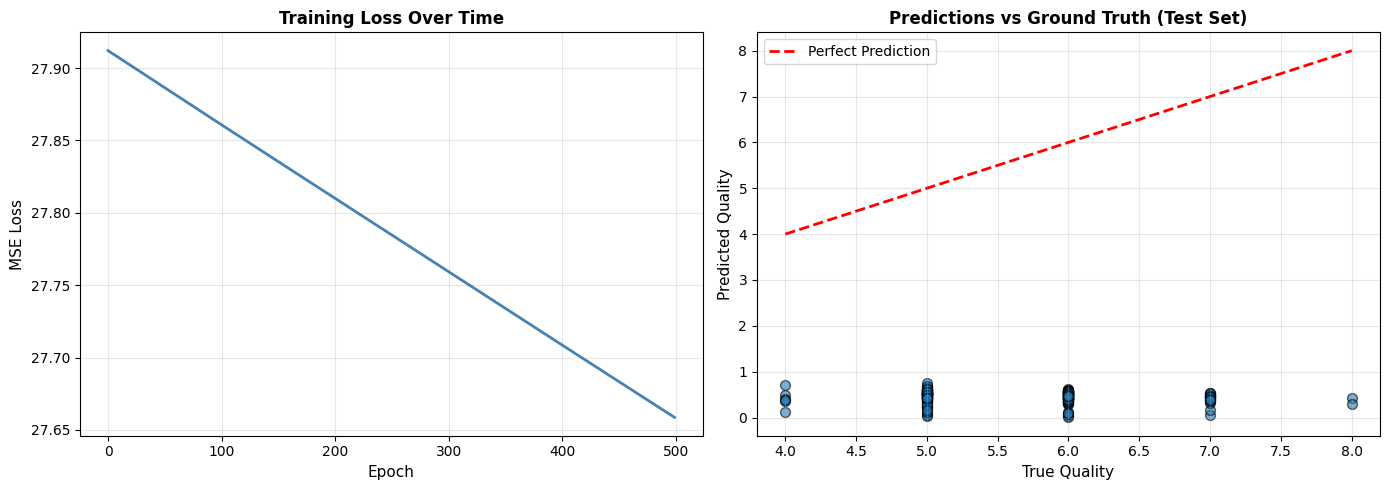


✅ Visualization saved as 'neural_network_results.png'


In [48]:
# ── VISUALIZATIONS ──────────────────────
# Plot training loss and predictions
plt.figure(figsize=(14, 5))

# Loss curve
plt.subplot(1, 2, 1)
plt.plot(losses, lw=2, color='steelblue')
plt.xlabel('Epoch', fontsize=11)
plt.ylabel('MSE Loss', fontsize=11)
plt.title('Training Loss Over Time', fontsize=12, fontweight='bold')
plt.grid(alpha=0.3)

# Actual vs Predicted
plt.subplot(1, 2, 2)
plt.scatter(y_test.flatten(), y_pred_test.flatten(), alpha=0.6, edgecolors='k', s=50)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Perfect Prediction')
plt.xlabel('True Quality', fontsize=11)
plt.ylabel('Predicted Quality', fontsize=11)
plt.title('Predictions vs Ground Truth (Test Set)', fontsize=12, fontweight='bold')
plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()
plt.savefig('neural_network_results.png', dpi=150)
plt.show()

print("\n✅ Visualization saved as 'neural_network_results.png'")